# Ensemble Feature Importance & Model Voting
---

## Imports & Configuration

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import joblib
import os
import warnings
import torch
import torch.nn as nn
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PROCESSED_DIR = './processed'
OUT_DIR = '../project/outputs/ensemble'
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/data',    exist_ok=True)

print('Config OK. Device:', DEVICE)

Config OK. Device: cpu


---
## Load Data

In [38]:
X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0)
X_val   = pd.read_csv(f'{PROCESSED_DIR}/X_val_scaled.csv',   index_col=0)
X_test  = pd.read_csv(f'{PROCESSED_DIR}/X_test_scaled.csv',  index_col=0)

y_reg_train = pd.read_csv(f'{PROCESSED_DIR}/y_reg_train.csv', index_col=0).squeeze()
y_reg_val   = pd.read_csv(f'{PROCESSED_DIR}/y_reg_val.csv',   index_col=0).squeeze()
y_reg_test  = pd.read_csv(f'{PROCESSED_DIR}/y_reg_test.csv',  index_col=0).squeeze()

nominal_cols = X_train.select_dtypes(include='object').columns.tolist()
X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=False)
X_val   = pd.get_dummies(X_val,   columns=nominal_cols, drop_first=False)
X_test  = pd.get_dummies(X_test,  columns=nominal_cols, drop_first=False)

X_train, X_val  = X_train.align(X_val,  join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)
X_val   = X_val.apply(pd.to_numeric,   errors='coerce').fillna(0).astype(np.float32)
X_test  = X_test.apply(pd.to_numeric,  errors='coerce').fillna(0).astype(np.float32)

feature_names = X_train.columns.tolist()
INPUT_DIM     = len(feature_names)

X_val_np      = np.asarray(X_val,      dtype=float)
X_test_np     = np.asarray(X_test,     dtype=float)
y_val_np      = np.asarray(y_reg_val,  dtype=float)
y_reg_test_np = np.asarray(y_reg_test, dtype=float)

print(f'Features : {INPUT_DIM}')
print(f'Test rows: {X_test_np.shape[0]}')

Features : 49
Test rows: 8000


---
## Model Definitions

In [39]:
class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128, 64, 32),
                 dropout_rates=(0.3, 0.3, 0.2, 0.0), output_dim=1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim, drop in zip(hidden_dims, dropout_rates):
            layers += [nn.Linear(in_dim, h_dim), nn.BatchNorm1d(h_dim), nn.ReLU()]
            if drop > 0:
                layers.append(nn.Dropout(drop))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class TabularCNN1D(nn.Module):
    def __init__(self, in_channels, conv_channels=(64, 128, 64),
                 fc_dims=(256, 64), dropout=0.3, output_dim=1):
        super().__init__()
        conv_blocks = []
        prev_ch = in_channels
        for ch in conv_channels:
            conv_blocks += [
                nn.Conv1d(prev_ch, ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(ch), nn.ReLU(), nn.Dropout(dropout),
            ]
            prev_ch = ch
        conv_blocks.append(nn.AdaptiveAvgPool1d(1))
        self.conv = nn.Sequential(*conv_blocks)
        fc_blocks = [nn.Flatten()]
        in_dim = prev_ch
        for h in fc_dims:
            fc_blocks += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout / 2)]
            in_dim = h
        fc_blocks.append(nn.Linear(in_dim, output_dim))
        self.fc = nn.Sequential(*fc_blocks)

    def forward(self, x):
        return self.fc(self.conv(x))


class FFNNSklearnWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            return self.model(t).cpu().numpy().flatten()


class CNNSklearnWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y):
        return self
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).unsqueeze(2).to(DEVICE)
            return self.model(t).cpu().numpy().flatten()


print('Model classes defined.')

Model classes defined.


In [40]:
class LinearRegression:

    def __init__(self):
        self.beta_ = None   # shape: (n_features + 1,)  [intercept first]

    @staticmethod
    def _add_bias(X):
        """Prepend a column of ones to X."""
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def fit(self, X, y):

        X_b = self._add_bias(np.asarray(X, dtype=float))
        y_  = np.asarray(y, dtype=float)

        A = X_b.T @ X_b
        b = X_b.T @ y_
        self.beta_ = np.linalg.solve(A, b)
        return self

    def predict(self, X):
        X_b = self._add_bias(np.asarray(X, dtype=float))
        return X_b @ self.beta_

    @property
    def intercept_(self):
        return self.beta_[0]

    @property
    def coef_(self):
        return self.beta_[1:]

In [41]:
class RidgeRegression:

    def __init__(self, lambda_=1.0):
        self.lambda_ = lambda_
        self.beta_   = None

    @staticmethod
    def _add_bias(X):
        """Prepend a column of ones to X."""
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def fit(self, X, y):
        X_b  = self._add_bias(np.asarray(X, dtype=float))
        y_   = np.asarray(y, dtype=float)

        n_params = X_b.shape[1]

        # Build penalty matrix
        pen      = self.lambda_ * np.eye(n_params)
        pen[0, 0] = 0.0

        A = X_b.T @ X_b + pen
        b = X_b.T @ y_
        self.beta_ = np.linalg.solve(A, b)
        return self

    def predict(self, X):
        X_b = self._add_bias(np.asarray(X, dtype=float))
        return X_b @ self.beta_

    @property
    def intercept_(self):
        return self.beta_[0]

    @property
    def coef_(self):
        return self.beta_[1:]

In [42]:
class LassoRegression:
    def __init__(self, lambda_=1.0, max_iter=1000, tol=1e-6, warm_start=False):
        self.lambda_    = lambda_
        self.max_iter   = max_iter
        self.tol        = tol
        self.warm_start = warm_start
        self.coef_      = None
        self.intercept_ = 0.0
        self.n_iter_    = 0

    @staticmethod
    def _soft_threshold(z, gamma):
        return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)

    def fit(self, X, y):
        X_ = np.asarray(X, dtype=float)
        y_ = np.asarray(y, dtype=float)
        n, p = X_.shape

        self.intercept_ = y_.mean()
        y_c = y_ - self.intercept_

        col_norms_sq = (X_ ** 2).sum(axis=0)
        col_norms_sq = np.where(col_norms_sq == 0, 1.0, col_norms_sq)

        # Warm start: reuse previous coef_ if available, else zero-init
        if not (self.warm_start and self.coef_ is not None and len(self.coef_) == p):
            self.coef_ = np.zeros(p)

        # Maintain residual vector to avoid recomputing X @ coef each inner step
        residual = y_c - X_ @ self.coef_

        for iteration in range(self.max_iter):
            beta_old = self.coef_.copy()

            for j in range(p):
                old_j = self.coef_[j]
                r_j   = residual + X_[:, j] * old_j        # cheap: add back column j
                z_j   = X_[:, j] @ r_j / col_norms_sq[j]
                self.coef_[j] = self._soft_threshold(z_j, self.lambda_ / col_norms_sq[j])
                residual = r_j - X_[:, j] * self.coef_[j]  # update residual in place

            self.intercept_ = y_.mean() - X_.mean(axis=0) @ self.coef_

            if np.max(np.abs(self.coef_ - beta_old)) < self.tol:
                self.n_iter_ = iteration + 1
                break
        else:
            self.n_iter_ = self.max_iter

        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.coef_ + self.intercept_

    @property
    def n_nonzero_(self):
        return int(np.sum(self.coef_ != 0))

---
## Load Trained Models

In [46]:
best_ols   = joblib.load('../GradeOptimiser/outputs/linear_regression/models/linear_reg.joblib')
best_ridge   = joblib.load('../GradeOptimiser/outputs/ridge_regression/models/ridge_reg.joblib')
best_lasso   = joblib.load('../GradeOptimiser/outputs/lasso_regression/models/lasso_reg.joblib')
best_dt   = joblib.load('../GradeOptimiser/outputs/decision_tree/models/reg_decision_tree.joblib')

ffnn_reg = FFNN(INPUT_DIM).to(DEVICE)
ffnn_reg.load_state_dict(torch.load('../GradeOptimiser/outputs/ffnn/models/ffnn_reg.pt', map_location=DEVICE))
ffnn_reg.eval()

cnn_reg = TabularCNN1D(INPUT_DIM).to(DEVICE)
cnn_reg.load_state_dict(torch.load('../GradeOptimiser/outputs/cnn/models/cnn_reg.pt', map_location=DEVICE))
cnn_reg.eval()

print('All models loaded.')

All models loaded.


---
## Extract Feature Importances Per Model

In [50]:
all_feature_names = feature_names  # 49 features

numeric_only_names = [f for f in all_feature_names
                      if X_train_raw[f].dtype != object] if False else \
                     pd.read_csv(f'{PROCESSED_DIR}/X_train_scaled.csv', index_col=0) \
                       .apply(pd.to_numeric, errors='coerce') \
                       .dropna(axis=1, how='all') \
                       .drop(columns=['student_id'], errors='ignore') \
                       .columns.tolist()

def align_to_full(values, name):
    n = len(values)
    candidates = [f for f in all_feature_names if f in numeric_only_names]
    model_features = candidates[:n] if len(candidates) >= n else all_feature_names[:n]
    s = pd.Series(np.abs(values), index=model_features, name=name)
    return s.reindex(all_feature_names, fill_value=0.0)

imp_ols   = align_to_full(best_ols.coef_,               'OLS')
imp_ridge = align_to_full(best_ridge.coef_,             'Ridge')
imp_lasso = pd.Series(np.abs(best_lasso.coef_),         index=all_feature_names, name='Lasso')
imp_dt    = pd.Series(best_dt.feature_importances_,     index=all_feature_names, name='DT')

perm_ffnn = permutation_importance(
    FFNNSklearnWrapper(ffnn_reg), X_test_np, y_reg_test_np,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_root_mean_squared_error'
)
imp_ffnn = pd.Series(perm_ffnn.importances_mean, index=all_feature_names, name='FFNN')

perm_cnn = permutation_importance(
    CNNSklearnWrapper(cnn_reg), X_test_np, y_reg_test_np,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring='neg_root_mean_squared_error'
)
imp_cnn = pd.Series(perm_cnn.importances_mean, index=all_feature_names, name='CNN')

raw_importances = pd.DataFrame([imp_ols, imp_ridge, imp_lasso, imp_dt, imp_ffnn, imp_cnn]).T
raw_importances.index.name = 'feature'

print('Raw importances shape:', raw_importances.shape)
raw_importances.head()

Raw importances shape: (49, 6)


,OLS,Ridge,Lasso,DT,FFNN,CNN
feature,,,,,,
student_id,0.087407,0.087184,0.066429,0.002640,0.014330,0.004507
age,0.010805,0.010690,0.000000,0.001001,-0.002235,-0.000777
study_hours_per_day,71.728638,1.535077,1.310216,0.057222,0.529601,0.365039
social_media_hours,0.135398,0.069527,0.000000,0.001904,-0.017145,0.003922
netflix_hours,0.198299,0.145611,0.063160,0.000000,-0.007991,0.000875


---
## Normalise Importances (Min-Max per Model)

In [51]:
def minmax_normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mn) / (mx - mn)

norm_importances = raw_importances.apply(minmax_normalize, axis=0)
norm_importances.to_csv(f'{OUT_DIR}/data/normalised_importances.csv')
print('Normalised importances saved.')
norm_importances.head()

Normalised importances saved.


,OLS,Ridge,Lasso,DT,FFNN,CNN
feature,,,,,,
student_id,0.000132,0.024889,0.019310,0.008037,0.066623,0.046940
age,0.000016,0.003052,0.000000,0.003047,0.047940,0.039255
study_hours_per_day,0.108544,0.438227,0.380855,0.174177,0.647796,0.571338
social_media_hours,0.000205,0.019848,0.000000,0.005795,0.031123,0.046090
netflix_hours,0.000300,0.041568,0.018359,0.000000,0.041448,0.041658


---
## Compute Model Weights (Val RMSE-Based)

In [55]:
y_val_np = np.asarray(y_reg_val, dtype=float)

n_ols   = len(best_ols.beta_) - 1
n_ridge = len(best_ridge.beta_) - 1

X_val_ols   = np.asarray(X_val.iloc[:, :n_ols],   dtype=float)
X_val_ridge = np.asarray(X_val.iloc[:, :n_ridge], dtype=float)
X_val_full  = np.asarray(X_val,                   dtype=float)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

val_rmses = {
    'OLS'  : rmse(y_val_np, best_ols.predict(X_val_ols)),
    'Ridge': rmse(y_val_np, best_ridge.predict(X_val_ridge)),
    'Lasso': rmse(y_val_np, best_lasso.predict(X_val_full)),
    'DT'   : rmse(y_val_np, best_dt.predict(X_val_full)),
    'FFNN' : rmse(y_val_np, FFNNSklearnWrapper(ffnn_reg).predict(X_val_full)),
    'CNN'  : rmse(y_val_np, CNNSklearnWrapper(cnn_reg).predict(X_val_full)),
}

rmse_series = pd.Series(val_rmses)
inv_rmse    = 1.0 / rmse_series
weights     = inv_rmse / inv_rmse.sum()

print('Val RMSEs:')
for m, v in val_rmses.items():
    print(f'  {m:6s}  RMSE={v:.4f}  weight={weights[m]:.4f}')

Val RMSEs:
  OLS     RMSE=897.6672  weight=0.0025
  Ridge   RMSE=11.7777  weight=0.1941
  Lasso   RMSE=10.9986  weight=0.2078
  DT      RMSE=12.0332  weight=0.1900
  FFNN    RMSE=11.3974  weight=0.2006
  CNN     RMSE=11.1515  weight=0.2050


---
## Weighted Ensemble Feature Importance

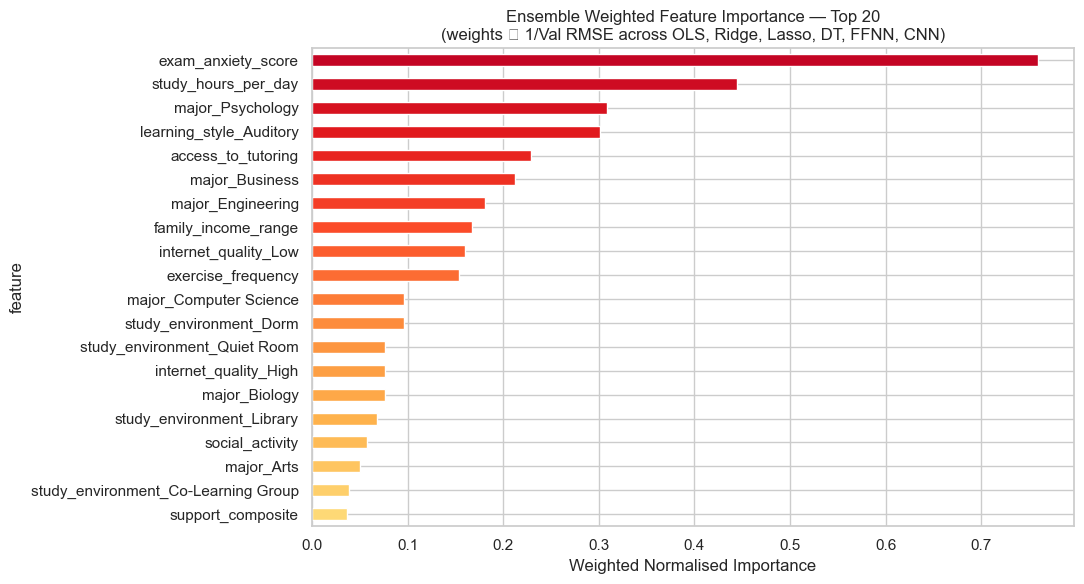

Weighted importance plot saved.


In [56]:
weighted_importance = (norm_importances * weights).sum(axis=1)
weighted_importance.name = 'weighted_importance'
weighted_importance = weighted_importance.sort_values(ascending=False)

weighted_importance.to_csv(f'{OUT_DIR}/data/weighted_ensemble_importance.csv')

top20 = weighted_importance.head(20)

plt.figure(figsize=(11, 6))
colors = cm.YlOrRd(np.linspace(0.85, 0.25, len(top20)))
top20.plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Weighted Normalised Importance')
plt.title('Ensemble Weighted Feature Importance — Top 20\n(weights ∝ 1/Val RMSE across OLS, Ridge, Lasso, DT, FFNN, CNN)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/ensemble_weighted_importance.png', dpi=150)
plt.show()
print('Weighted importance plot saved.')

---
## Per-Model Importance Heatmap

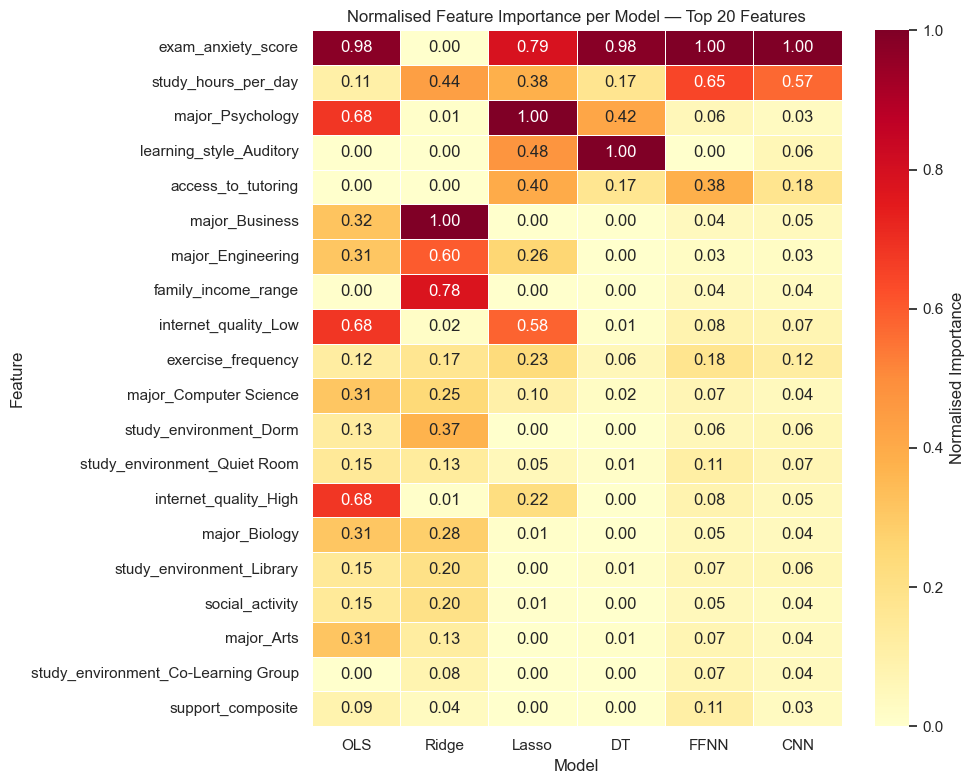

In [57]:
top20_features = weighted_importance.head(20).index
heatmap_data   = norm_importances.loc[top20_features]

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.4, cbar_kws={'label': 'Normalised Importance'}
)
plt.title('Normalised Feature Importance per Model — Top 20 Features')
plt.xlabel('Model')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/importance_heatmap.png', dpi=150)
plt.show()

---
## Rank-Based Voting Ensemble

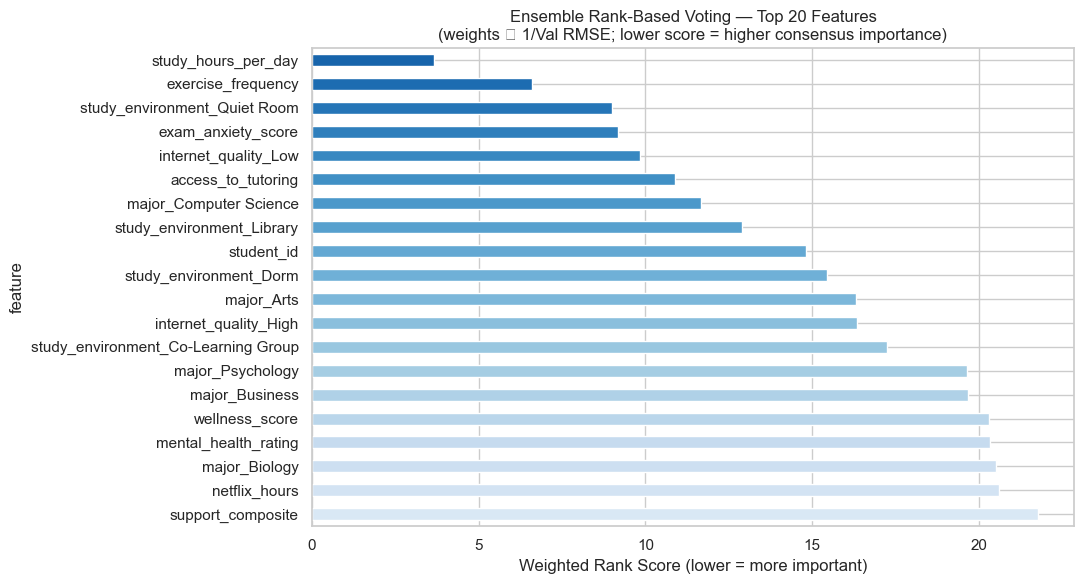

Rank voting plot saved.


In [58]:
rank_df = norm_importances.rank(ascending=False, method='min')

weighted_rank = (rank_df * weights).sum(axis=1)
feature_ranking = weighted_rank.sort_values(ascending=True)

feature_ranking.to_csv(f'{OUT_DIR}/data/weighted_rank_voting.csv')

top20_ranked = feature_ranking.head(20)

plt.figure(figsize=(11, 6))
colors = cm.Blues_r(np.linspace(0.2, 0.85, len(top20_ranked)))
top20_ranked.plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.xlabel('Weighted Rank Score (lower = more important)')
plt.title('Ensemble Rank-Based Voting — Top 20 Features\n(weights ∝ 1/Val RMSE; lower score = higher consensus importance)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/ensemble_rank_voting.png', dpi=150)
plt.show()
print('Rank voting plot saved.')

---
## Rank Agreement Across Models

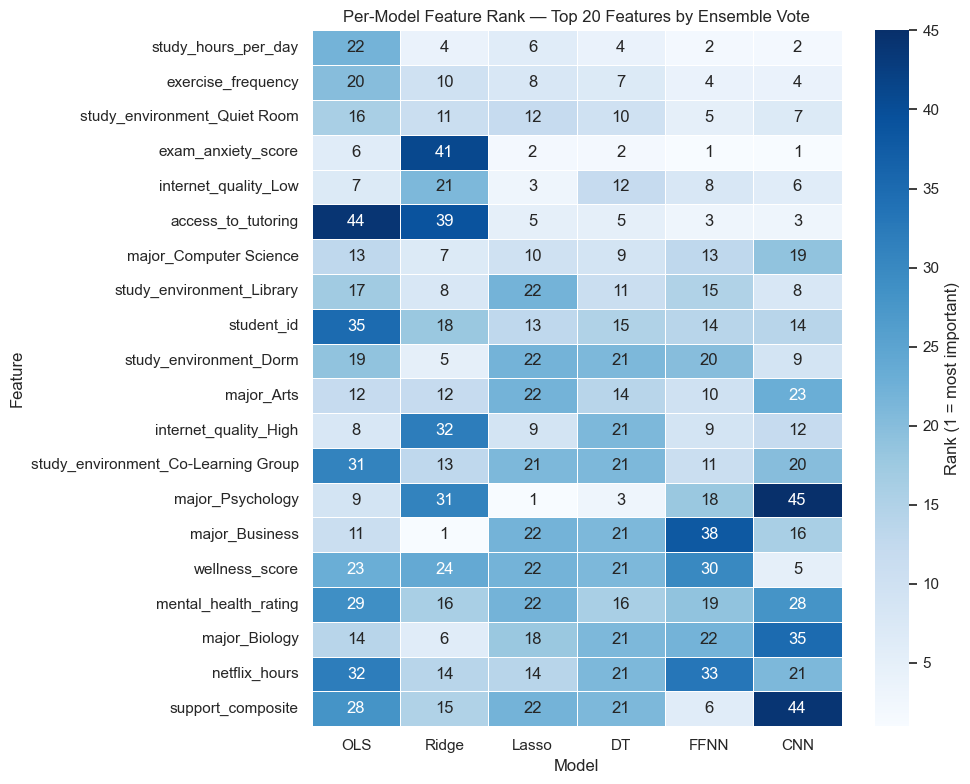

In [59]:
top20_features_ranked = feature_ranking.head(20).index
rank_heatmap = rank_df.loc[top20_features_ranked]

plt.figure(figsize=(10, 8))
sns.heatmap(
    rank_heatmap, annot=True, fmt='.0f', cmap='Blues',
    linewidths=0.4, cbar_kws={'label': 'Rank (1 = most important)'}
)
plt.title('Per-Model Feature Rank — Top 20 Features by Ensemble Vote')
plt.xlabel('Model')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/rank_agreement_heatmap.png', dpi=150)
plt.show()

---
## Comparison: Weighted Importance vs Rank Voting

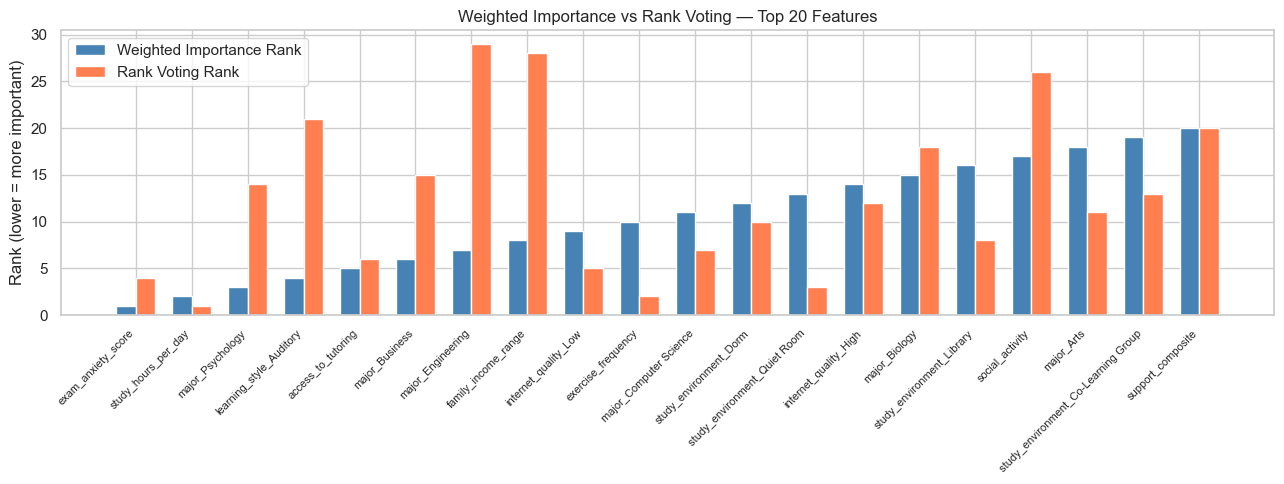


Top 20 features — rank comparison:
                                     Importance Rank  Vote Rank  rank_diff
feature                                                                   
exam_anxiety_score                                 1          4          3
study_hours_per_day                                2          1          1
major_Psychology                                   3         14         11
learning_style_Auditory                            4         21         17
access_to_tutoring                                 5          6          1
major_Business                                     6         15          9
major_Engineering                                  7         29         22
family_income_range                                8         28         20
internet_quality_Low                               9          5          4
exercise_frequency                                10          2          8
major_Computer Science                            11          7 

In [60]:
importance_rank = pd.Series(
    range(1, len(weighted_importance) + 1),
    index=weighted_importance.index,
    name='Importance Rank'
)
vote_rank = pd.Series(
    range(1, len(feature_ranking) + 1),
    index=feature_ranking.index,
    name='Vote Rank'
)

comparison = pd.concat([importance_rank, vote_rank], axis=1)
comparison['rank_diff'] = (comparison['Importance Rank'] - comparison['Vote Rank']).abs()
comparison = comparison.sort_values('Importance Rank')
comparison.to_csv(f'{OUT_DIR}/data/importance_vs_vote_rank.csv')

top20_comp = comparison.head(20)
x = np.arange(len(top20_comp))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, top20_comp['Importance Rank'], width, label='Weighted Importance Rank', color='steelblue')
ax.bar(x + width/2, top20_comp['Vote Rank'],       width, label='Rank Voting Rank',         color='coral')
ax.set_xticks(x)
ax.set_xticklabels(top20_comp.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Rank (lower = more important)')
ax.set_title('Weighted Importance vs Rank Voting — Top 20 Features')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/importance_vs_vote_comparison.png', dpi=150)
plt.show()

print('\nTop 20 features — rank comparison:')
print(top20_comp.to_string())

---
## Model Weight Summary

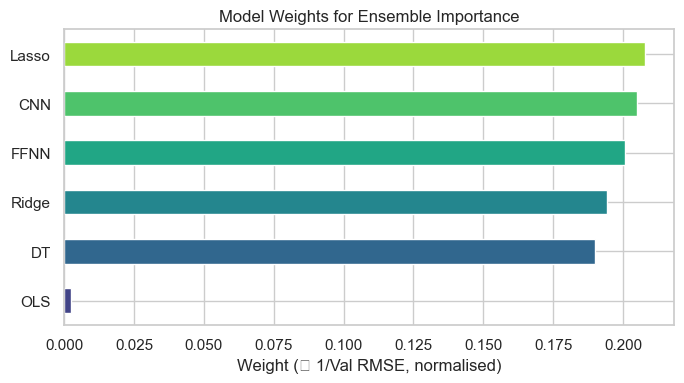


Final model weights:
  Lasso   0.2078
  CNN     0.2050
  FFNN    0.2006
  Ridge   0.1941
  DT      0.1900
  OLS     0.0025


In [61]:
fig, ax = plt.subplots(figsize=(7, 4))
colors  = cm.viridis(np.linspace(0.2, 0.85, len(weights)))
weights.sort_values().plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Weight (∝ 1/Val RMSE, normalised)')
ax.set_title('Model Weights for Ensemble Importance')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/figures/model_weights.png', dpi=150)
plt.show()

print('\nFinal model weights:')
for m, w in weights.sort_values(ascending=False).items():
    print(f'  {m:6s}  {w:.4f}')